<a href="https://colab.research.google.com/github/NguyenManhCuong1512/AI/blob/main/Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, load_wine
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    StratifiedKFold, GridSearchCV
)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier  # pip install xgboost

# Dataset dùng xuyên suốt
bc   = load_breast_cancer()   # nhị phân, 569 mẫu, 30 đặc trưng
iris = load_iris()            # 3 lớp,   150 mẫu,  4 đặc trưng
wine = load_wine()            # 3 lớp,   178 mẫu, 13 đặc trưng

X_bc, y_bc     = bc.data,   bc.target
X_iris, y_iris = iris.data, iris.target
X_wine, y_wine = wine.data, wine.target

AUC — AdaBoost: 0.9868


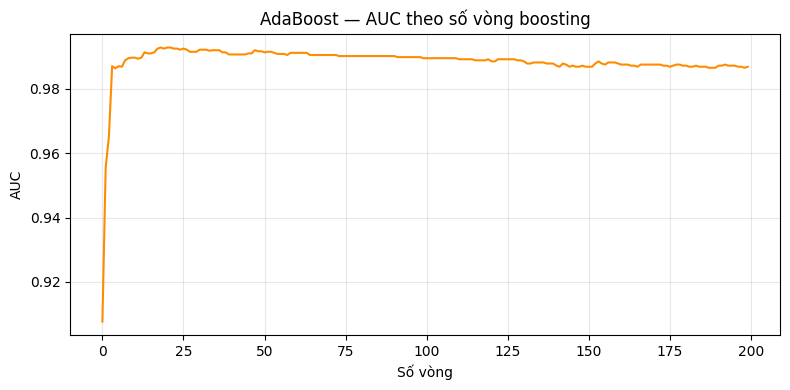

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42
)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # weak learner = stump
    n_estimators=200, learning_rate=0.1, random_state=42
)
ada.fit(X_train, y_train)
print(f"AUC — AdaBoost: {roc_auc_score(y_test, ada.predict_proba(X_test)[:, 1]):.4f}")

# AUC theo số vòng
staged_auc = [roc_auc_score(y_test, p[:, 1]) for p in ada.staged_predict_proba(X_test)]
plt.figure(figsize=(8, 4))
plt.plot(staged_auc, color="darkorange")
plt.xlabel("Số vòng")
plt.ylabel("AUC")
plt.title("AdaBoost — AUC theo số vòng boosting")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

AUC — Gradient Boosting: 0.9927


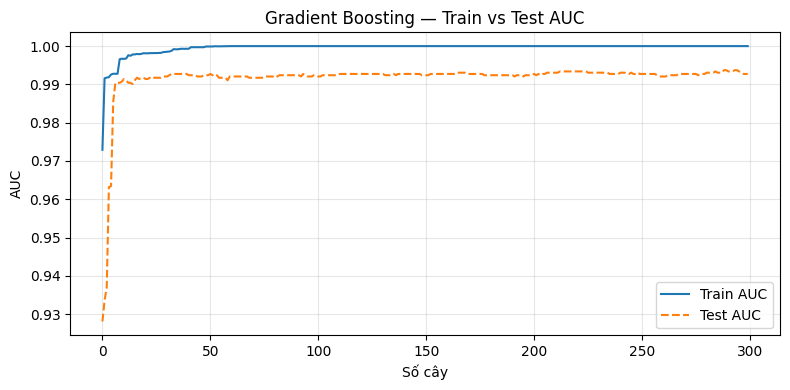

In [18]:
gb = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=3, subsample=0.8, random_state=42
)
gb.fit(X_train, y_train)
print(f"AUC — Gradient Boosting: {roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1]):.4f}")

# Train vs. Test AUC theo số cây
train_auc = [roc_auc_score(y_train, p[:, 1]) for p in gb.staged_predict_proba(X_train)]
test_auc  = [roc_auc_score(y_test,  p[:, 1]) for p in gb.staged_predict_proba(X_test)]

plt.figure(figsize=(8, 4))
plt.plot(train_auc, label="Train AUC")
plt.plot(test_auc,  label="Test AUC", linestyle="--")
plt.xlabel("Số cây")
plt.ylabel("AUC")
plt.legend()
plt.title("Gradient Boosting — Train vs Test AUC")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    eval_metric="auc", early_stopping_rounds=30,
    random_state=42, verbosity=0
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

print(f"AUC — XGBoost:           {roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]):.4f}")
print(f"Số cây tốt nhất:         {xgb.best_iteration}")

AUC — XGBoost:           0.9934
Số cây tốt nhất:         3


In [20]:
models = {
    "Decision Tree":     DecisionTreeClassifier(max_depth=5, random_state=42),
    "Bagging":           BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Random Forest":     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "AdaBoost":          AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    "XGBoost":           XGBClassifier(n_estimators=200, learning_rate=0.05, eval_metric="logloss", verbosity=0, random_state=42),
}

print(f"{'Model':<22} {'AUC mean':>10} {'AUC std':>10}")
print("-" * 44)
for name, model in models.items():
    scores = cross_val_score(model, X_bc, y_bc, cv=5, scoring="roc_auc", n_jobs=-1)
    print(f"{name:<22} {scores.mean():>10.4f} {scores.std():>10.4f}")

Model                    AUC mean    AUC std
--------------------------------------------
Decision Tree              0.9160     0.0223
Bagging                    0.9875     0.0111
Random Forest              0.9915     0.0066
AdaBoost                   0.9906     0.0072
Gradient Boosting          0.9919     0.0062
XGBoost                    0.9935     0.0050
